# ECON3203 Group Project: Sensational

## Explore & Prepare data

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [53]:
# load data
sample_url="https://drive.google.com/uc?export=download&id=1ekCjJOTjGD0OASErwVnwhJuPD0hFfCEF"
out_url=sample_url
db_sample = pd.read_csv(sample_url)
db_out = pd.read_csv(out_url)

In [ ]:
def create_frames(db_sample: pd.DataFrame):
    ladder_map = {
        "probation": "1probation",
        "apprentice": "2apprentice",
        "level1": "3level1",
        "level2": "4level2",
        "level3": "5level3"
    }

    db_sample["ladder"] = db_sample["ladder"].replace(ladder_map)
    # creating copies for both read and math scores
    math = db_sample.copy()
    math = math.drop("score_read", axis=1)
    math = math.dropna(subset="score_math")
    read = db_sample.copy()
    read = read.drop("score_math", axis=1)
    read = read.dropna(subset="score_read")
    

    return read, math



In [57]:
read, math = create_frames(db_sample)

In [58]:
math.head()

,score_math,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
0,602.0,male,1980 Q2,free,cauc,small,rural,master,3level1,6.0,cauc,36.0,72.0
1,434.0,male,1980 Q3,free,afam,small,rural,bachelor,2apprentice,1.0,cauc,24.0,57.0
2,520.0,male,1980 Q2,non-free,cauc,regular+aide,suburban,bachelor,3level1,5.0,afam,22.0,51.0
3,454.0,female,1979 Q4,free,cauc,regular+aide,rural,bachelor,3level1,11.0,cauc,4.0,6.0
4,473.0,female,1980 Q3,non-free,cauc,regular,rural,bachelor,3level1,2.0,cauc,40.0,76.0


In [59]:
read.head()

,score_read,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
0,474.0,male,1980 Q2,free,cauc,small,rural,master,3level1,6.0,cauc,36.0,72.0
1,403.0,male,1980 Q3,free,afam,small,rural,bachelor,2apprentice,1.0,cauc,24.0,57.0
2,455.0,male,1980 Q2,non-free,cauc,regular+aide,suburban,bachelor,3level1,5.0,afam,22.0,51.0
3,405.0,female,1979 Q4,free,cauc,regular+aide,rural,bachelor,3level1,11.0,cauc,4.0,6.0
4,433.0,female,1980 Q3,non-free,cauc,regular,rural,bachelor,3level1,2.0,cauc,40.0,76.0


In [ ]:
agg = ["min","median","mean","max"]
ladder_agg = read.groupby("ladder", as_index=False)["score_read"].agg(agg)
ladder_agg

,ladder,min,median,mean,max
0,1probation,346.0,431.0,434.680365,580.0
1,2apprentice,380.0,427.0,430.749347,554.0
2,3level1,358.0,433.0,437.299509,627.0
3,4level2,382.0,446.5,453.166667,605.0
4,5level3,403.0,453.0,461.951220,580.0


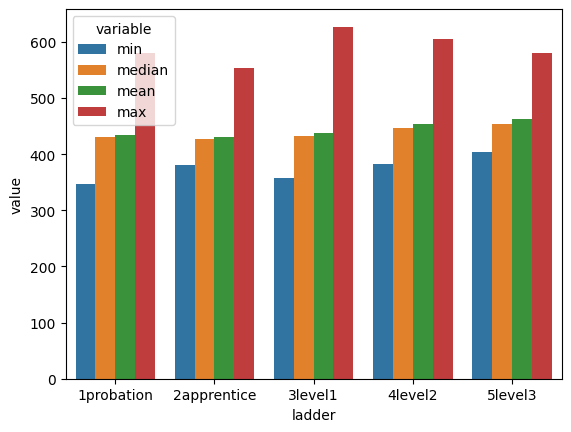

In [ ]:
sns.barplot(ladder_agg, x="ladder", y="value", hue="variable")

ladder = read.groupby("ladder", as_index=False)["score_read"]

<Axes: xlabel='ladder', ylabel='score_read'>

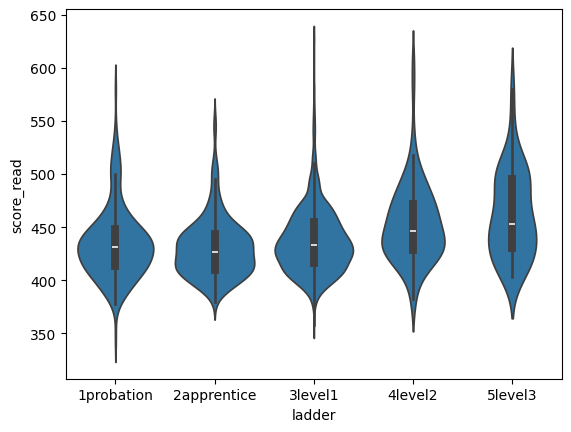

In [49]:
sns.violinplot(read.sort_values(by="ladder"), x="ladder", y="score_read")